In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
import itertools
import time
import random
import networkx as nx
import seaborn as sns 

# загружаем данные и смотрим размер
df = pd.read_csv('../data/kz.csv')
print("Размер данных:", df.shape)

Размер данных: (2633521, 8)


In [3]:
# оставляем только нужное и убираем пустые категории
df = df[['order_id', 'category_code']].dropna(subset=['category_code'])
print("После очистки:", df.shape)
df.head()

После очистки: (2021319, 2)


,order_id,category_code
0,2294359932054536986,electronics.tablet
1,2294359932054536986,electronics.tablet
2,2294444024058086220,electronics.audio.headphone
3,2294444024058086220,electronics.audio.headphone
5,2295716521449619559,furniture.kitchen.table


In [4]:
# формируем список транзакций (уникальные категории в каждом заказе)
transactions = df.groupby('order_id')['category_code'].apply(lambda x: list(set(x))).tolist()
transactions = [t for t in transactions if len(t) >= 2]  # только покупки с >2 товарами
print(f"Транзакций: {len(transactions)}")

# статистика
lengths = [len(t) for t in transactions]
print(f"Средняя длина: {np.mean(lengths):.2f}, макс: {max(lengths)}, мин: {min(lengths)}")
print(f"Уникальных категорий: {len(set(item for t in transactions for item in t))}")

Транзакций: 382000
Средняя длина: 2.80, макс: 19, мин: 2
Уникальных категорий: 444


In [5]:
def apriori(transactions, min_support=0.01):
    """ищет частые наборы алгоритмом apriori"""
    n_trans = len(transactions)
    min_count = n_trans * min_support
    
    # считаем частоту одиночных элементов
    item_counts = Counter(item for trans in transactions for item in trans)
    L1 = {frozenset([item]): count for item, count in item_counts.items() if count >= min_count}
    
    if not L1:
        return {}
    
    freq_itemsets = {tuple(sorted(itemset)): count/n_trans for itemset, count in L1.items()}
    
    # итеративно ищем наборы длины 2, 3, ...
    k = 2
    prev_freq = L1
    
    while prev_freq:
        # генерируем кандидатов размера k
        candidates = set()
        items = list(prev_freq.keys())
        for i in range(len(items)):
            for j in range(i+1, len(items)):
                candidate = items[i] | items[j]
                if len(candidate) == k:
                    candidates.add(candidate)
        
        if not candidates:
            break
        
        # считаем поддержку
        cand_counts = defaultdict(int)
        for trans in transactions:
            trans_set = set(trans)
            for cand in candidates:
                if cand.issubset(trans_set):
                    cand_counts[cand] += 1
        
        # оставляем частые
        new_freq = {cand: count for cand, count in cand_counts.items() if count >= min_count}
        if not new_freq:
            break
        
        for itemset, count in new_freq.items():
            freq_itemsets[tuple(sorted(itemset))] = count / n_trans
        
        prev_freq = new_freq
        k += 1
    
    return freq_itemsets

In [6]:
# берем выборку для быстрого теста
sample_size = 50000
sample_trans = [transactions[i] for i in np.random.choice(len(transactions), 
                min(sample_size, len(transactions)), replace=False)]

print(f"Размер выборки: {len(sample_trans)}")
start = time.time()
freq_itemsets = apriori(sample_trans, min_support=0.005)
print(f"Время: {time.time() - start:.2f} сек, найдено наборов: {len(freq_itemsets)}")

Размер выборки: 50000
Время: 5.90 сек, найдено наборов: 266


In [7]:
def generate_rules(freq_itemsets, n_trans, min_confidence=0.5, min_lift=1.0,
                   max_ante_len=3, max_cons_len=1):
    """создает ассоциативные правила из частых наборов"""
    rules = []
    
    for itemset, supp_abs in freq_itemsets.items():
        if len(itemset) < 2:
            continue
            
        # перебираем все возможные разбиения на антецедент и консеквент
        for ante_len in range(1, min(len(itemset), max_ante_len + 1)):
            for antecedent in itertools.combinations(itemset, ante_len):
                antecedent = set(antecedent)
                consequent = set(itemset) - antecedent
                
                if len(consequent) > max_cons_len:
                    continue
                
                ante_key = tuple(sorted(antecedent))
                cons_key = tuple(sorted(consequent))
                
                # проверяем наличие антецедента
                supp_ante = freq_itemsets.get(ante_key, 0)
                if supp_ante == 0:
                    continue
                
                # считаем confidence
                confidence = supp_abs / supp_ante
                if confidence < min_confidence:
                    continue
                
                # проверяем консеквент
                supp_cons = freq_itemsets.get(cons_key, 0)
                if supp_cons == 0:
                    continue
                
                # метрики качества правила
                supp = supp_abs / n_trans
                supp_a = supp_ante / n_trans
                supp_c = supp_cons / n_trans
                
                lift = supp / (supp_a * supp_c)
                if lift < min_lift:
                    continue
                
                conviction = (1 - supp_c) / (1 - confidence) if confidence < 1 else float('inf')
                leverage = supp - supp_a * supp_c
                
                rules.append({
                    'antecedent': ante_key,
                    'consequent': cons_key,
                    'support': supp,
                    'confidence': confidence,
                    'lift': lift,
                    'conviction': conviction,
                    'leverage': leverage
                })
    
    return rules

In [18]:
# генерируем правила из найденных частых наборов
N_trans = len(transactions)
rules_fp = generate_rules(freq_fp, N_trans, min_confidence=0.5, min_lift=1.0)
print(f"Количество правил: {len(rules_fp)}")

Количество правил: 174


In [9]:
class FPNode:
    """узел fp-дерева"""
    __slots__ = ('item', 'count', 'parent', 'children', 'node_link')
    
    def __init__(self, item, count=1, parent=None):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.node_link = None

In [10]:
def fpgrowth(transactions, min_support):
    """находит частые наборы через fp-growth (возвращает абсолютную поддержку)"""
    
    # считаем частоту всех элементов
    freq = {}
    for trans in transactions:
        for item in trans:
            freq[item] = freq.get(item, 0) + 1
    
    # убираем редкие элементы
    freq = {item: count for item, count in freq.items() if count >= min_support}
    
    if not freq:
        return {}
    
    # сортируем транзакции по убыванию частоты элементов
    sorted_trans = []
    for trans in transactions:
        filtered = [item for item in trans if item in freq]
        filtered.sort(key=lambda x: freq[x], reverse=True)
        if filtered:
            sorted_trans.append(filtered)
    
    # рекурсивная функция поиска
    def mine(transactions, min_support, prefix, freq_itemsets):
        # частоты в текущих транзакциях
        local_freq = {}
        for trans in transactions:
            for item in trans:
                local_freq[item] = local_freq.get(item, 0) + 1
        
        # оставляем частые
        local_freq = {k: v for k, v in local_freq.items() if v >= min_support}
        if not local_freq:
            return
        
        items_sorted = sorted(local_freq.keys(), key=lambda x: local_freq[x], reverse=True)
        
        # для каждого элемента создаем условную базу
        for item in items_sorted:
            new_prefix = prefix + [item]
            freq_itemsets[tuple(sorted(new_prefix))] = local_freq[item]
            
            # формируем условные транзакции
            cond_trans = []
            for trans in transactions:
                if item in trans:
                    filtered = [x for x in trans if x in local_freq and x != item]
                    if filtered:
                        cond_trans.append(filtered)
            
            # рекурсивно обрабатываем
            if cond_trans:
                mine(cond_trans, min_support, new_prefix, freq_itemsets)
    
    freq_itemsets = {}
    mine(sorted_trans, min_support, [], freq_itemsets)
    return freq_itemsets

In [11]:
# сравниваем производительность двух алгоритмов
min_supp = 0.005
N_trans = len(transactions)

print("Запуск Apriori...")
start = time.time()
freq_apriori = apriori(transactions, min_support=min_supp)
time_apriori = time.time() - start

print("Запуск FP-Growth...")
start = time.time()
freq_fp = fpgrowth(transactions, int(N_trans * min_supp))
time_fp = time.time() - start

print(f"\nApriori: {time_apriori:.2f} сек, наборов: {len(freq_apriori)}")
print(f"FP-Growth: {time_fp:.2f} сек, наборов: {len(freq_fp)}")

# генерируем правила из результатов fp-growth
rules_fp = generate_rules(freq_fp, N_trans, min_confidence=0.5, min_lift=1.0,
                          max_ante_len=3, max_cons_len=1)
print(f"Правил: {len(rules_fp)}")

# топ-10 по lift
top_lift = sorted(rules_fp, key=lambda x: x['lift'], reverse=True)[:10]
print("\nТоп-10 правил по lift:")
for i, r in enumerate(top_lift, 1):
    print(f"{i}. {r['antecedent']} -> {r['consequent']}: "
          f"lift={r['lift']:.2f}, conf={r['confidence']:.2f}, supp={r['support']:.4f}")

Запуск Apriori...
Запуск FP-Growth...

Apriori: 43.38 сек, наборов: 267
FP-Growth: 4.50 сек, наборов: 267
Правил: 174

Топ-10 правил по lift:
1. ('25.46', '4.63', 'electronics.smartphone') -> ('3.89',): lift=54.38, conf=1.00, supp=0.0052
2. ('25.46', '4.63') -> ('3.89',): lift=54.38, conf=1.00, supp=0.0052
3. ('25.46', '4.63', 'electronics.video.tv') -> ('3.89',): lift=54.38, conf=1.00, supp=0.0052
4. ('25.46', 'electronics.smartphone', 'electronics.video.tv') -> ('3.89',): lift=54.33, conf=1.00, supp=0.0059
5. ('25.46', 'electronics.video.tv') -> ('3.89',): lift=54.33, conf=1.00, supp=0.0059
6. ('25.46', 'electronics.smartphone') -> ('3.89',): lift=54.05, conf=0.99, supp=0.0059
7. ('25.46',) -> ('3.89',): lift=53.98, conf=0.99, supp=0.0059
8. ('11.57', 'electronics.smartphone', 'electronics.video.tv') -> ('3.89',): lift=53.19, conf=0.97, supp=0.0053
9. ('29.63', '4.63', 'electronics.video.tv') -> ('3.89',): lift=49.95, conf=0.91, supp=0.0055
10. ('4.63', 'electronics.smartphone', 'ele

min_support=0.001
  наборов: 1317, правил: 928
min_support=0.002
  наборов: 645, правил: 416
min_support=0.003
  наборов: 454, правил: 305
min_support=0.004
  наборов: 335, правил: 208
min_support=0.005
  наборов: 267, правил: 174
min_support=0.0075
  наборов: 158, правил: 86
min_support=0.01
  наборов: 129, правил: 71
min_support=0.02
  наборов: 66, правил: 34


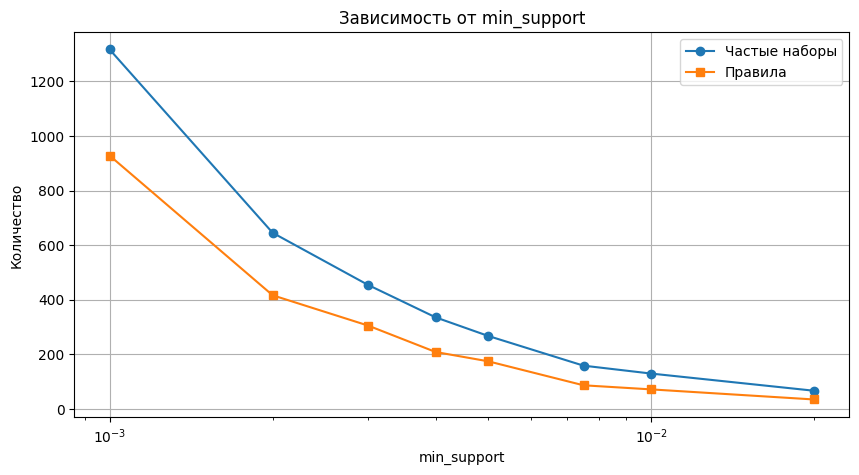

In [13]:
# смотрим как min_support влияет на количество наборов и правил
min_supports = [0.001, 0.002, 0.003, 0.004, 0.005, 0.0075, 0.01, 0.02]
n_itemsets = []
n_rules = []

for ms in min_supports:
    print(f"min_support={ms}")
    freq = fpgrowth(transactions, int(N_trans * ms))
    n_itemsets.append(len(freq))
    
    rules = generate_rules(freq, N_trans, min_confidence=0.5, min_lift=1.0)
    n_rules.append(len(rules))
    print(f"  наборов: {len(freq)}, правил: {len(rules)}")

# строим график
plt.figure(figsize=(10, 5))
plt.plot(min_supports, n_itemsets, 'o-', label='Частые наборы')
plt.plot(min_supports, n_rules, 's-', label='Правила')
plt.xlabel('min_support')
plt.ylabel('Количество')
plt.xscale('log')
plt.legend()
plt.grid(True)
plt.title('Зависимость от min_support')
plt.show()

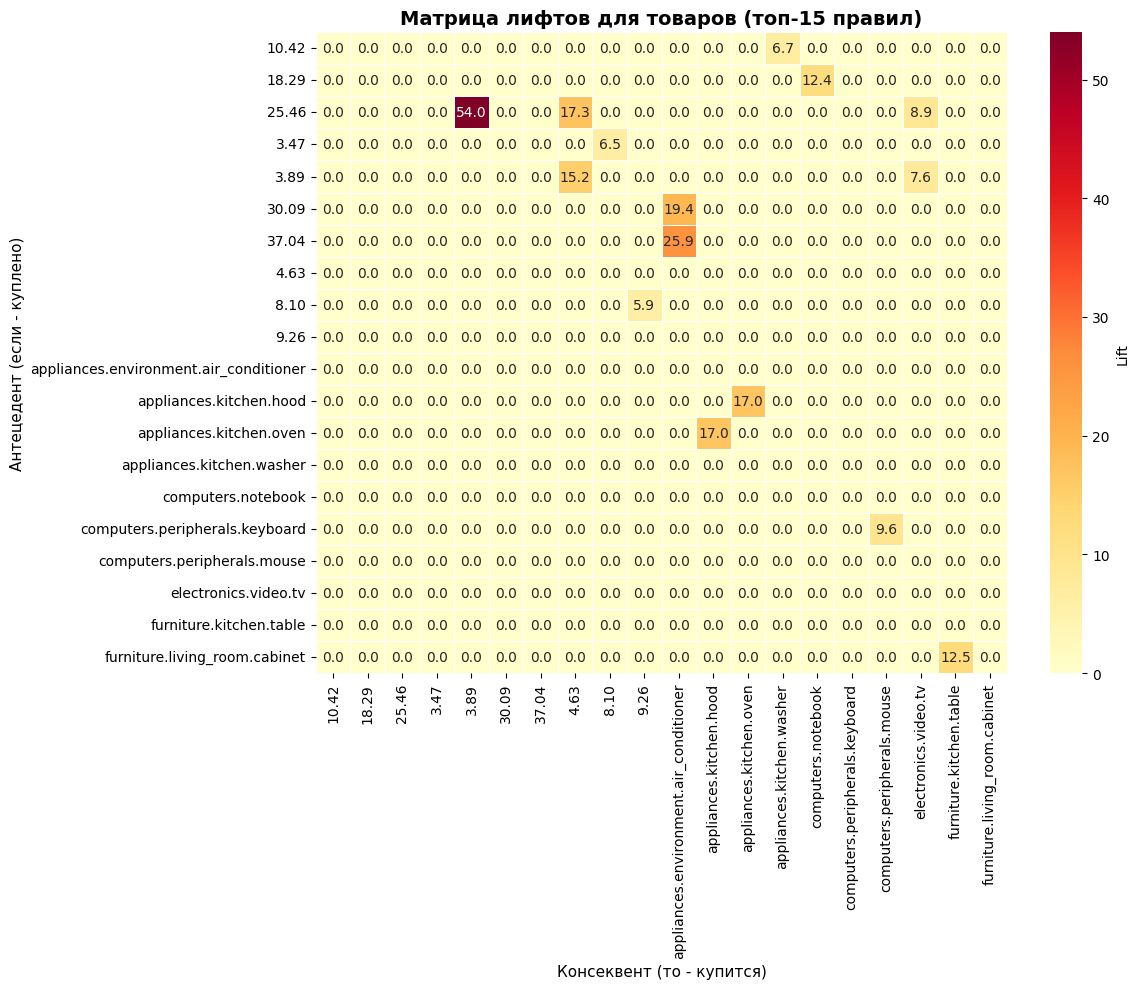

In [32]:
# матрица лифтов для топ товаров
def plot_lift_heatmap(rules, top_n=15):
    """построить матрицу лифтов для одиночных товаров"""
    import pandas as pd
    
    # собираем только правила "один товар → один товар"
    pairs = []
    for r in sorted(rules, key=lambda x: x['lift'], reverse=True):
        if len(r['antecedent']) == 1 and len(r['consequent']) == 1:
            ante = r['antecedent'][0]
            cons = r['consequent'][0]
            pairs.append({
                'from': ante,
                'to': cons,
                'lift': r['lift']
            })
            if len(pairs) >= top_n:
                break
    
    if not pairs:
        print("Не найдены правила 'один товар → один товар'")
        return
    
    df_pairs = pd.DataFrame(pairs)
    
    # создаем матрицу
    items = sorted(set(df_pairs['from'].tolist() + df_pairs['to'].tolist()))
    matrix = pd.DataFrame(0.0, index=items, columns=items)
    
    for _, row in df_pairs.iterrows():
        matrix.loc[row['from'], row['to']] = row['lift']
    
    # рисуем
    plt.figure(figsize=(12, 10))
    sns.heatmap(matrix, annot=True, fmt='.1f', cmap='YlOrRd', 
                cbar_kws={'label': 'Lift'}, linewidths=0.5,
                vmin=0, vmax=matrix.max().max())
    plt.title('Матрица лифтов для товаров (топ-15 правил)', fontsize=14, fontweight='bold')
    plt.xlabel('Консеквент (то - купится)', fontsize=11)
    plt.ylabel('Антецедент (если - куплено)', fontsize=11)
    plt.tight_layout()
    plt.show()

plot_lift_heatmap(rules_fp, top_n=15)

Размер: 1000
  Apriori: 0.23 сек, FP-Growth: 0.01 сек
Размер: 5000
  Apriori: 1.16 сек, FP-Growth: 0.05 сек
Размер: 10000
  Apriori: 2.28 сек, FP-Growth: 0.09 сек
Размер: 20000
  Apriori: 4.56 сек, FP-Growth: 0.19 сек
Размер: 50000
  Apriori: 11.36 сек, FP-Growth: 0.48 сек


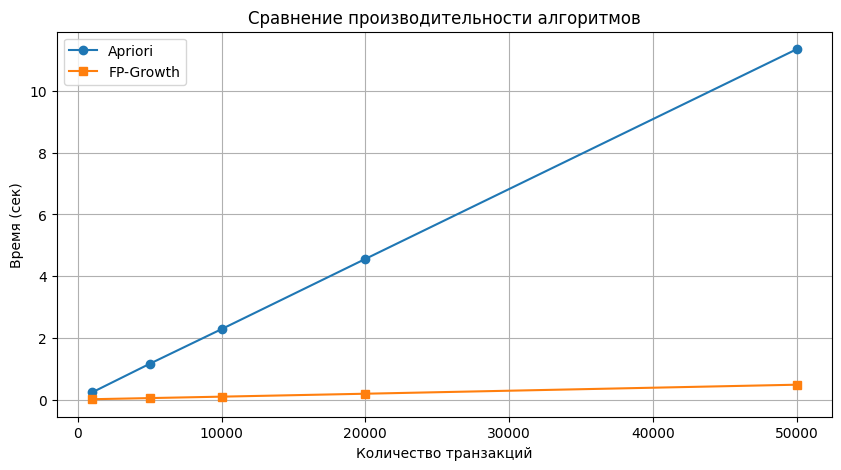

In [14]:
def generate_synthetic_transactions(n_trans, avg_len=5, n_items=100):
    """генерирует случайные транзакции для тестов"""
    transactions = []
    for _ in range(n_trans):
        length = int(np.random.poisson(avg_len - 1) + 1)
        trans = random.sample(range(n_items), min(length, n_items))
        transactions.append([str(i) for i in trans])
    return transactions

# сравниваем скорость на разных размерах
sizes = [1000, 5000, 10000, 20000, 50000]
time_apriori_list = []
time_fpgrowth_list = []

for size in sizes:
    print(f"Размер: {size}")
    trans_synth = generate_synthetic_transactions(size, avg_len=5, n_items=100)
    
    start = time.time()
    freq_a = apriori(trans_synth, min_support=0.01)
    time_apriori_list.append(time.time() - start)
    
    start = time.time()
    freq_f = fpgrowth(trans_synth, int(size * 0.01))
    time_fpgrowth_list.append(time.time() - start)
    
    print(f"  Apriori: {time_apriori_list[-1]:.2f} сек, FP-Growth: {time_fpgrowth_list[-1]:.2f} сек")

# график сравнения производительности
plt.figure(figsize=(10, 5))
plt.plot(sizes, time_apriori_list, 'o-', label='Apriori')
plt.plot(sizes, time_fpgrowth_list, 's-', label='FP-Growth')
plt.xlabel('Количество транзакций')
plt.ylabel('Время (сек)')
plt.legend()
plt.grid(True)
plt.title('Сравнение производительности алгоритмов')
plt.show()

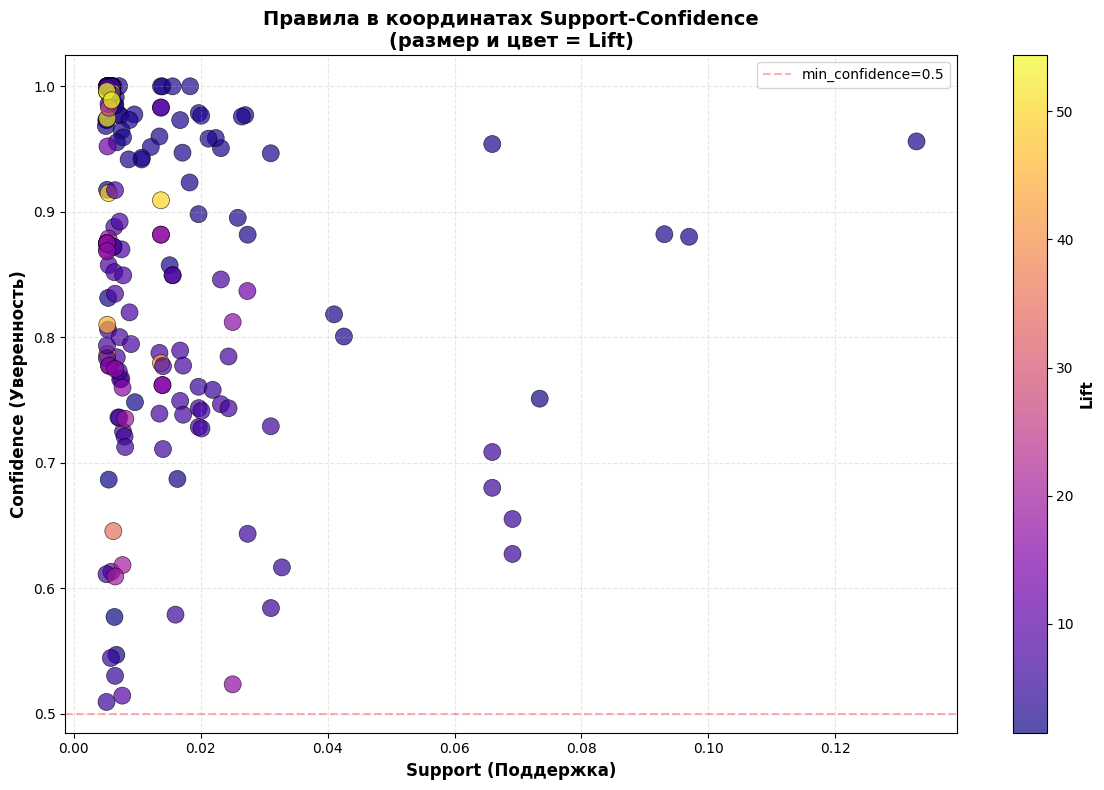


Статистика правил:
  Всего правил: 174
  Support: мин=0.0050, макс=0.1328, средн=0.0150
  Confidence: мин=0.5095, макс=1.0000, средн=0.8528
  Lift: мин=1.50, макс=54.38, средн=10.37


In [29]:
# диаграмма рассеяния support-confidence с цветом по lift
def plot_support_confidence_lift(rules):
    """рассеяние support-confidence, цвет = lift"""
    
    if not rules:
        print("Нет правил для визуализации")
        return
    
    supports = np.array([r['support'] for r in rules])
    confidences = np.array([r['confidence'] for r in rules])
    lifts = np.array([r['lift'] for r in rules])
    
    plt.figure(figsize=(12, 8))
    
    # scatter plot
    scatter = plt.scatter(supports, confidences, c=lifts, 
                         s=150, cmap='plasma', alpha=0.7,
                         edgecolors='black', linewidth=0.5)
    
    plt.xlabel('Support (Поддержка)', fontsize=12, fontweight='bold')
    plt.ylabel('Confidence (Уверенность)', fontsize=12, fontweight='bold')
    plt.title('Правила в координатах Support-Confidence\n(размер и цвет = Lift)', 
              fontsize=14, fontweight='bold')
    
    # цветовая шкала
    cbar = plt.colorbar(scatter)
    cbar.set_label('Lift', fontsize=11, fontweight='bold')
    
    # сетка
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # добавляем линии для ориентира
    plt.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='min_confidence=0.5')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # выводим статистику
    print("\nСтатистика правил:")
    print(f"  Всего правил: {len(rules)}")
    print(f"  Support: мин={supports.min():.4f}, макс={supports.max():.4f}, средн={supports.mean():.4f}")
    print(f"  Confidence: мин={confidences.min():.4f}, макс={confidences.max():.4f}, средн={confidences.mean():.4f}")
    print(f"  Lift: мин={lifts.min():.2f}, макс={lifts.max():.2f}, средн={lifts.mean():.2f}")

plot_support_confidence_lift(rules_fp)

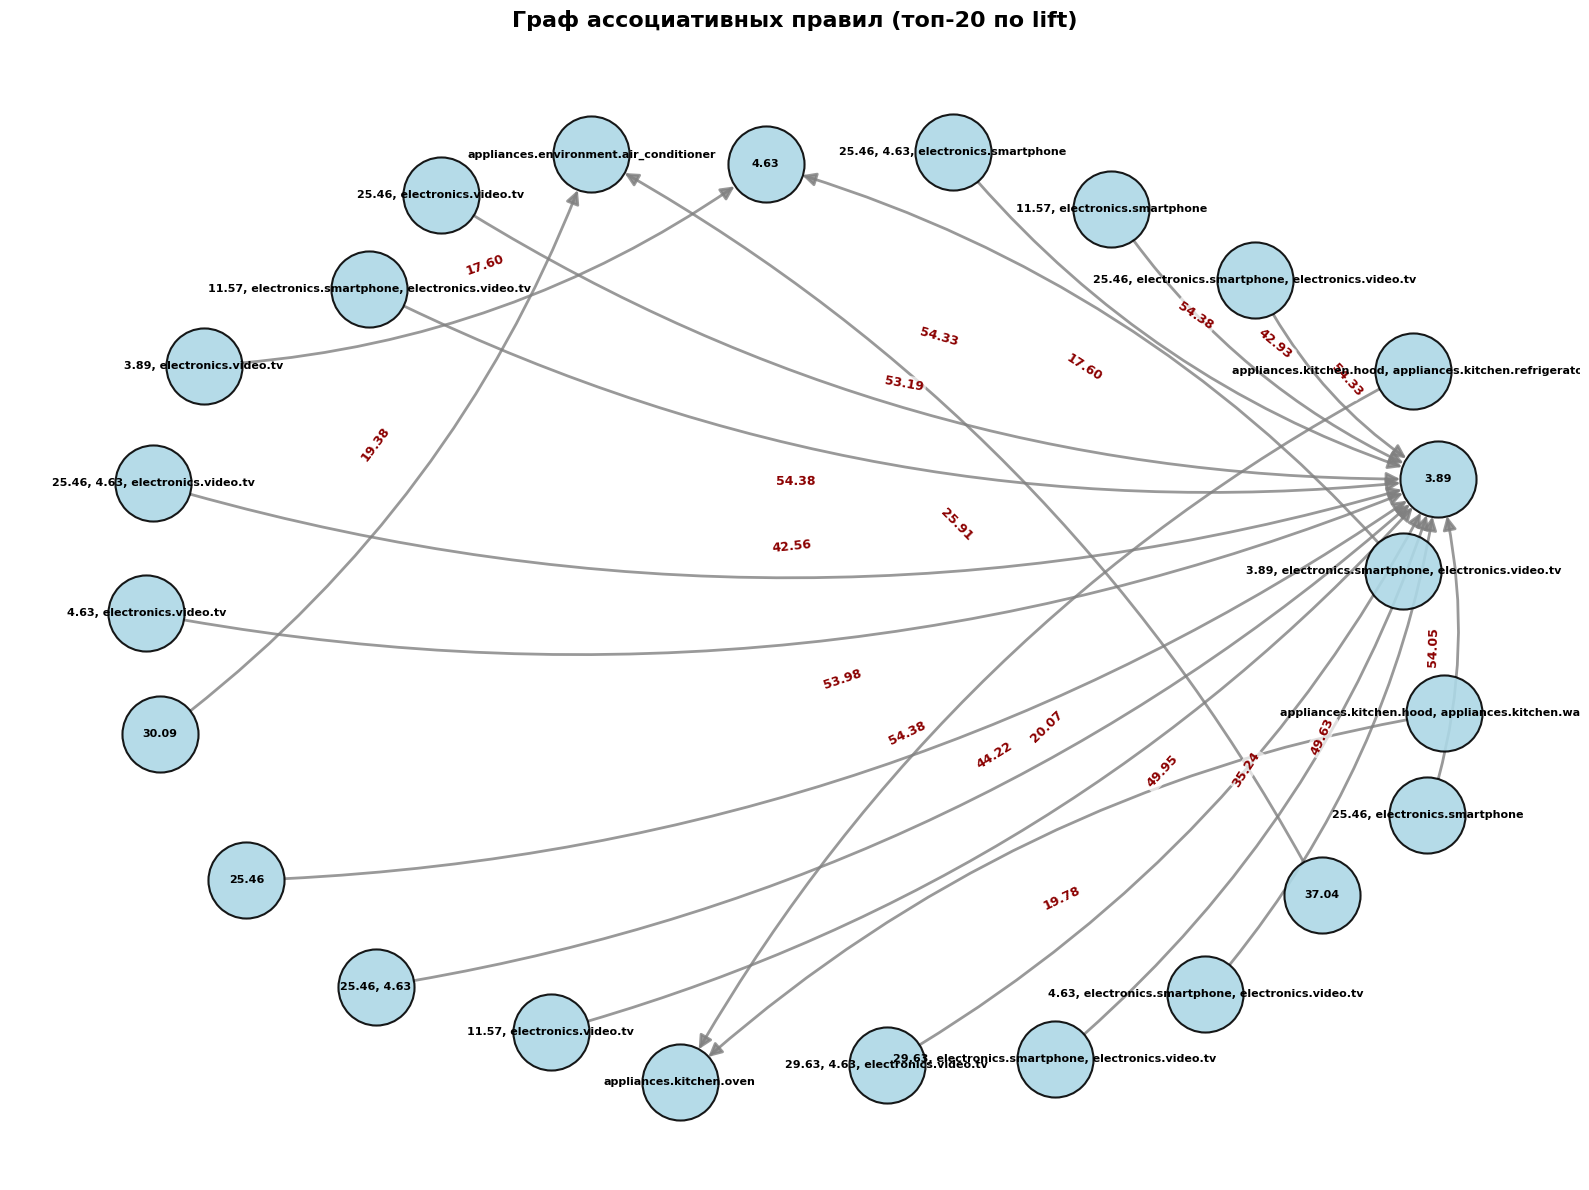

In [25]:
def plot_rules_graph(rules, top_n=20, metric='lift', title=''):
    """строит граф топ правил с улучшенной визуализацией"""
    top_rules = sorted(rules, key=lambda x: x[metric], reverse=True)[:top_n]
    
    if not top_rules:
        print("Нет правил для визуализации")
        return
    
    # создаем граф
    G = nx.DiGraph()
    edge_labels = {}
    
    for rule in top_rules:
        # полные названия без сокращений
        ante = ', '.join(rule['antecedent'])
        cons = ', '.join(rule['consequent'])
        
        G.add_edge(ante, cons)
        
        # метка для ребра (значение выбранной метрики)
        edge_labels[(ante, cons)] = f"{rule[metric]:.2f}"
    
    # раскладка с большим расстоянием
    pos = nx.spring_layout(G, k=4, iterations=100, seed=42)
    
    plt.figure(figsize=(16, 12))
    
    # рисуем узлы
    nx.draw_networkx_nodes(G, pos, 
                          node_size=3000, 
                          node_color='lightblue', 
                          alpha=0.9,
                          edgecolors='black',
                          linewidths=1.5)
    
    # рисуем ребра со стрелками 
    nx.draw_networkx_edges(G, pos, 
                          edge_color='gray', 
                          arrows=True,
                          arrowsize=20, 
                          arrowstyle='-|>',
                          width=2.0,
                          alpha=0.8,
                          connectionstyle='arc3,rad=0.15',
                          node_size=3000)  # учитываем размер узлов
    
    # рисуем подписи узлов (полные названия)
    nx.draw_networkx_labels(G, pos, 
                            font_size=8, 
                            font_weight='bold',
                            font_family='DejaVu Sans')
    
    # рисуем метки ребер
    nx.draw_networkx_edge_labels(G, pos, 
                                 edge_labels, 
                                 font_size=9,
                                 font_color='darkred',
                                 font_weight='bold',
                                 bbox=dict(facecolor='white', 
                                           edgecolor='none', 
                                           alpha=0.7,
                                           boxstyle='round,pad=0.2'))
    
    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# визуализируем топ-20 правил
plot_rules_graph(rules_fp, top_n=20, metric='lift', 
                 title='Граф ассоциативных правил (топ-20 по lift)')